## Importing libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter
import yaml
import random
from PIL import Image
import hashlib
import shutil

## Defining paths

In [6]:
PROJECT_ROOT = Path.cwd().parent
DATASET_ROOT = PROJECT_ROOT / "data" / "ElectroCom61 A Multiclass Dataset for Detection of Electronic Components" / "ElectroCom-61_v2"

SPLITS = ["train", "valid", "test"]

image_dirs = {split: DATASET_ROOT / split / "images" for split in SPLITS}
label_dirs = {split: DATASET_ROOT / split / "labels" for split in SPLITS}

for split in SPLITS:
    print(split, "images: ", image_dirs[split].exists(), "labels: ", label_dirs[split].exists())

train images:  True labels:  True
valid images:  True labels:  True
test images:  True labels:  True


In [10]:
with open(DATASET_ROOT / "data.yaml") as f:
    data = yaml.safe_load(f)

names = data["names"]

for class_id, name in enumerate(names):
    print(f"Class {class_id}: {name}")

Class 0: 1-5-Volt-Battery
Class 1: 3-3-Volt-Battery
Class 2: 7-Segment-Display
Class 3: 9-Volt-Battery
Class 4: Arduino-Mega
Class 5: Arduino-Nano
Class 6: Arduino-Uno
Class 7: BJT-Transistor
Class 8: Bluetooth-Module
Class 9: Breadboard
Class 10: Bridge-Rectifier
Class 11: Buck-Converter
Class 12: Buzzer
Class 13: Capacitor-10mf
Class 14: Capacitor-470mf
Class 15: DC-Motor
Class 16: Diode
Class 17: ESP32
Class 18: ESP32-CAM
Class 19: FT-232-USB-Serial-Module
Class 20: Film-Capacitor
Class 21: Fuse
Class 22: Fuse-Base
Class 23: GSM-Module
Class 24: Gas-Sensor
Class 25: Heat-Sink
Class 26: High-Voltage-Ceramic-Capacitor
Class 27: Humidity-Sensor
Class 28: IC-Base-14-Pin
Class 29: IC-Base-28-Pin
Class 30: IC-Chip
Class 31: IGBT
Class 32: IR-Sensor
Class 33: Inductor
Class 34: Keypad
Class 35: LCD-Display
Class 36: LDR-Sensor
Class 37: LED-Light
Class 38: Low-Voltage-Ceramic-Capacitor
Class 39: MLC-Capacitor
Class 40: MOSFET
Class 41: Motion-Sensor
Class 42: Motor-Driver
Class 43: NTC-The

## Visualizing a random sample image and its detections

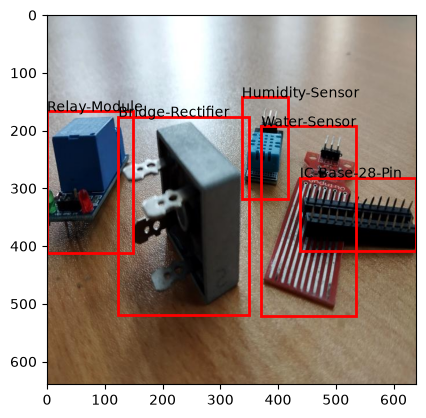

In [15]:
image_path = random.choice(list(image_dirs["train"].glob("*.jpg")))
label_path = label_dirs["train"] / f"{image_path.stem}.txt"

image = Image.open(image_path)
width, height = image.size

fig, ax = plt.subplots()
ax.imshow(image)


with open(label_path) as f:
    for line in f:
        class_id, x_center, y_center, w, h = map(float, line.split())

        x_center *= width
        y_center *= height
        w *= width
        h *= height

        x = x_center - w / 2
        y = y_center - h / 2

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, names[int(class_id)])

plt.show()

We can notice in a lot of examples that the detections cells of the components often overlap and we will inspect it further by determing which class pairs overlap the most.

In [18]:
def box_to_xyxy(x_center, y_center, w, h):
    x1 = x_center - w / 2
    y1 = y_center - h / 2
    x2 = x_center + w / 2
    y2 = y_center + h / 2
    return x1, y1, x2, y2

def iou(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1, inter_y1 = max(xa1, xb1), max(ya1, yb1)
    inter_x2, inter_y2 = min(xa2, xb2), min(ya2, yb2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)

    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0

overlap_rows = []

for label_file in label_dirs["train"].glob("*.txt"):
    boxes = []
    with open(label_file) as f:
        for line in f:
            if not line.strip():
                continue
            class_id, x_center, y_center, w, h = map(float, line.split())
            boxes.append((int(class_id), box_to_xyxy(x_center, y_center, w, h)))

    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            overlap = iou(boxes[i][1], boxes[j][1])
            if overlap > 0.1:
                overlap_rows.append({
                    "image": label_file.stem,
                    "class_a": names[boxes[i][0]],
                    "class_b": names[boxes[j][0]],
                    "iou": overlap
                })

overlap_df = pd.DataFrame(overlap_rows).sort_values("iou", ascending=False)
print(f"Overlapping box pairs (IoU > 0.1): {len(overlap_df)}")
overlap_df.head(20)

Overlapping box pairs (IoU > 0.1): 426


,image,class_a,class_b,iou
213,IMG_20240306_115904_jpg.rf.2d6be427e61479d544b...,Arduino-Mega,Arduino-Mega,0.967000
148,IMG_20240220_132854_jpg.rf.b314375ae5ca4aa711a...,Push-Switch,Push-Switch,0.776596
206,IMG_20240303_111339_jpg.rf.905065d80bbf0766924...,3-3-Volt-Battery,FT-232-USB-Serial-Module,0.570612
325,IMG_20240309_114746_jpg.rf.31898ecf0767fb0d9ec...,Water-Sensor,Bridge-Rectifier,0.556961
230,IMG_20240306_120824_jpg.rf.0860fa4de8109757c99...,3-3-Volt-Battery,ESP32-CAM,0.533677
52,IMG20240309112846_jpg.rf.f5c297484ac2c0223d076...,Bridge-Rectifier,IC-Base-28-Pin,0.509462
120,IMG_20240220_114326_jpg.rf.9625f8dba4ffc6926a3...,Bluetooth-Module,Bluetooth-Module,0.489424
87,IMG20240309114753_jpg.rf.48c3f832d546acf5bbe5e...,Water-Sensor,Bridge-Rectifier,0.485902
205,IMG_20240303_111333_jpg.rf.ecb3883b245341608ee...,Raindrops-Module,ESP32-CAM,0.476378
283,IMG_20240309_112836_jpg.rf.0501ce8c820cac903c4...,Bridge-Rectifier,IC-Base-28-Pin,0.467476


Visualize the first overlap of 2 Arduino-Mega to confirm

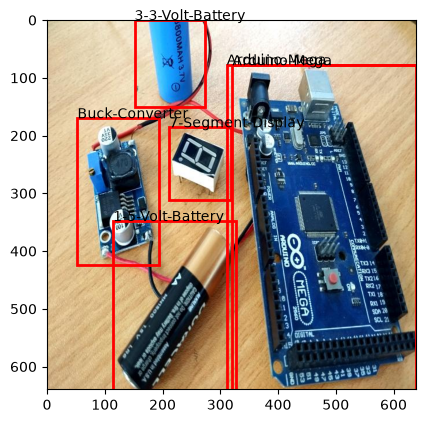

In [19]:
dup_image_name = "IMG_20240306_115904_jpg.rf.2d6be427e61479d544b"
dup_label_file = next(label_dirs["train"].glob(f"{dup_image_name}*.txt"))
dup_image_file = next(image_dirs["train"].glob(f"{dup_image_name}*.jpg"))

image = Image.open(dup_image_file)
width, height = image.size

fig, ax = plt.subplots()
ax.imshow(image)

with open(dup_label_file) as f:
    for line in f:
        class_id, x_center, y_center, w, h = map(float, line.split())

        x_center *= width
        y_center *= height
        w *= width
        h *= height

        x = x_center - w / 2
        y = y_center - h / 2

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, names[int(class_id)])

plt.show()

x=0.4375 y=0.2070 w=0.0586 h=0.0586
x=0.4305 y=0.6625 w=0.0578 h=0.0688
x=0.4359 y=0.2047 w=0.0586 h=0.0719


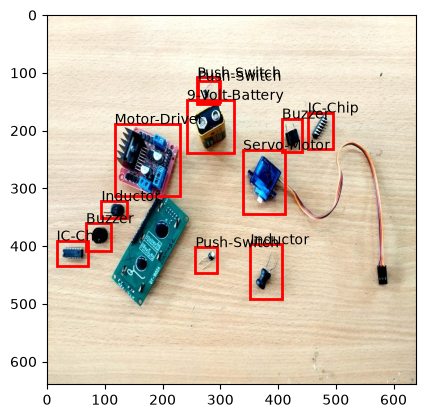

In [23]:
dup_image_name = "IMG_20240220_132854_jpg.rf.b314375ae5ca4aa711a"
dup_label_file = next(label_dirs["train"].glob(f"{dup_image_name}*.txt"))
dup_image_file = next(image_dirs["train"].glob(f"{dup_image_name}*.jpg"))

image = Image.open(dup_image_file)
width, height = image.size

fig, ax = plt.subplots()
ax.imshow(image)

with open(dup_label_file) as f:
    for line in f:
        class_id, x_center, y_center, w, h = map(float, line.split())

        if names[int(class_id)] == "Push-Switch":
            print(f"x={x_center:.4f} y={y_center:.4f} w={w:.4f} h={h:.4f}")

        x_center *= width
        y_center *= height
        w *= width
        h *= height

        x = x_center - w / 2
        y = y_center - h / 2

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, names[int(class_id)])

plt.show()

One component isn't labeled, found a false negative.

We can assume if IoU is too high ( > 0.7 ), we don't have an overlap but rather duplicates in the label file.

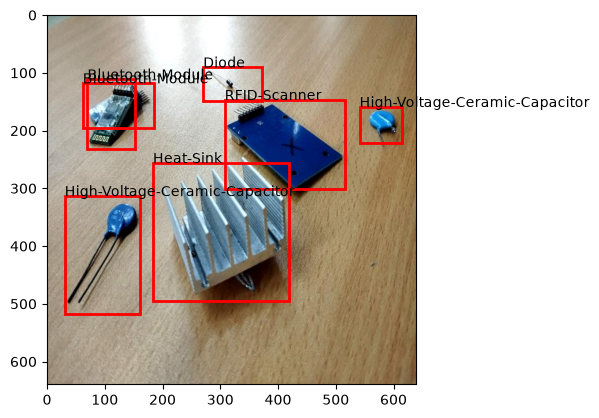

In [20]:
dup_image_name = "IMG_20240220_114326_jpg.rf.9625f8dba4ffc6926a3"
dup_label_file = next(label_dirs["train"].glob(f"{dup_image_name}*.txt"))
dup_image_file = next(image_dirs["train"].glob(f"{dup_image_name}*.jpg"))

image = Image.open(dup_image_file)
width, height = image.size

fig, ax = plt.subplots()
ax.imshow(image)

with open(dup_label_file) as f:
    for line in f:
        class_id, x_center, y_center, w, h = map(float, line.split())

        x_center *= width
        y_center *= height
        w *= width
        h *= height

        x = x_center - w / 2
        y = y_center - h / 2

        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y, names[int(class_id)])

plt.show()

In [26]:
REVIEW_THRESHOLD = 0.7

candidates = []

for split in SPLITS:
    candidates_split = []
    for label_file in label_dirs[split].glob("*.txt"):
        with open(label_file) as f:
            lines = [line for line in f if line.strip()]

        boxes = []
        for line in lines:
            class_id, x_center, y_center, w, h = map(float, line.split())
            boxes.append((int(class_id), box_to_xyxy(x_center, y_center, w, h)))

        for i in range(len(boxes)):
            for j in range(i + 1, len(boxes)):
                overlap = iou(boxes[i][1], boxes[j][1])
                if overlap > REVIEW_THRESHOLD:
                    candidates_split.append({
                        "file": label_file.name,
                        "class_a": names[boxes[i][0]],
                        "class_b": names[boxes[j][0]],
                        "iou": overlap
                    })
    candidates.extend(candidates_split)

candidates_df = pd.DataFrame(candidates).sort_values("iou", ascending=False)
candidates_df

,file,class_a,class_b,iou
1,IMG_20240306_115904_jpg.rf.2d6be427e61479d544b...,Arduino-Mega,Arduino-Mega,0.967000
0,IMG_20240220_132854_jpg.rf.b314375ae5ca4aa711a...,Push-Switch,Push-Switch,0.776596


We only have detection cell duplicates in only 2 of our training samples, which we will remove from our training data as to feed the model optimal data.

In [27]:
DEDUP_IOU_THRESHOLD = 0.7

dedup_report = []

for split in SPLITS:
    for label_file in label_dirs[split].glob("*.txt"):
        with open(label_file) as f:
            lines = [line for line in f if line.strip()]

        boxes = []
        for line in lines:
            class_id, x_center, y_center, w, h = map(float, line.split())
            boxes.append((int(class_id), box_to_xyxy(x_center, y_center, w, h)))

        to_drop = set()
        for i in range(len(boxes)):
            for j in range(i + 1, len(boxes)):
                if boxes[i][0] == boxes[j][0] and iou(boxes[i][1], boxes[j][1]) > DEDUP_IOU_THRESHOLD:
                    to_drop.add(j)

        if to_drop:
            dedup_report.append({
                "split": split,
                "file": label_file.name,
                "dropped": len(to_drop)
            })

        kept_lines = [line for idx, line in enumerate(lines) if idx not in to_drop]

        if to_drop:
            with open(label_file, "w") as f:
                f.writelines(kept_lines)

print(f"Files with duplicates removed: {len(dedup_report)}")
pd.DataFrame(dedup_report)

Files with duplicates removed: 2


,split,file,dropped
0,train,IMG_20240220_132854_jpg.rf.b314375ae5ca4aa711a...,1
1,train,IMG_20240306_115904_jpg.rf.2d6be427e61479d544b...,1


## Number of objects per image

Mean: 6.2151556156968875
Median: 6.0
Min: 1
Max: 16


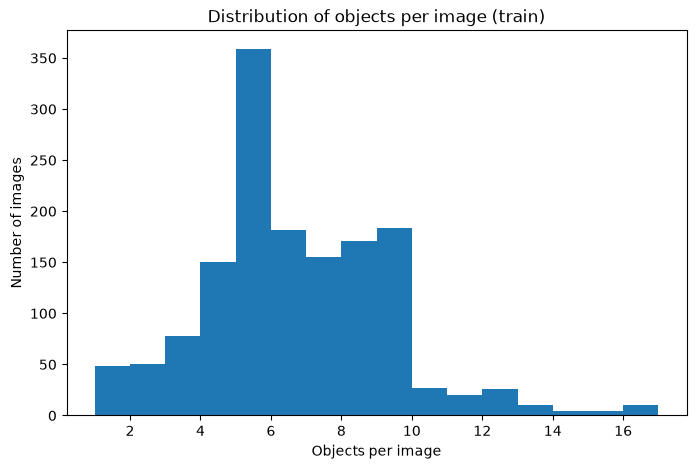

In [28]:
objects_per_image = []

for label_file in label_dirs["train"].glob("*.txt"):
    with open(label_file) as f:
        objects_per_image.append(len([line for line in f if line.strip()]))

print("Mean:", np.mean(objects_per_image))
print("Median:", np.median(objects_per_image))
print("Min:", np.min(objects_per_image))
print("Max:", np.max(objects_per_image))

plt.figure(figsize=(8, 5))
plt.hist(objects_per_image, bins=range(1, max(objects_per_image) + 2))
plt.xlabel("Objects per image")
plt.ylabel("Number of images")
plt.title("Distribution of objects per image (train)")
plt.show()

## Number of objects per class

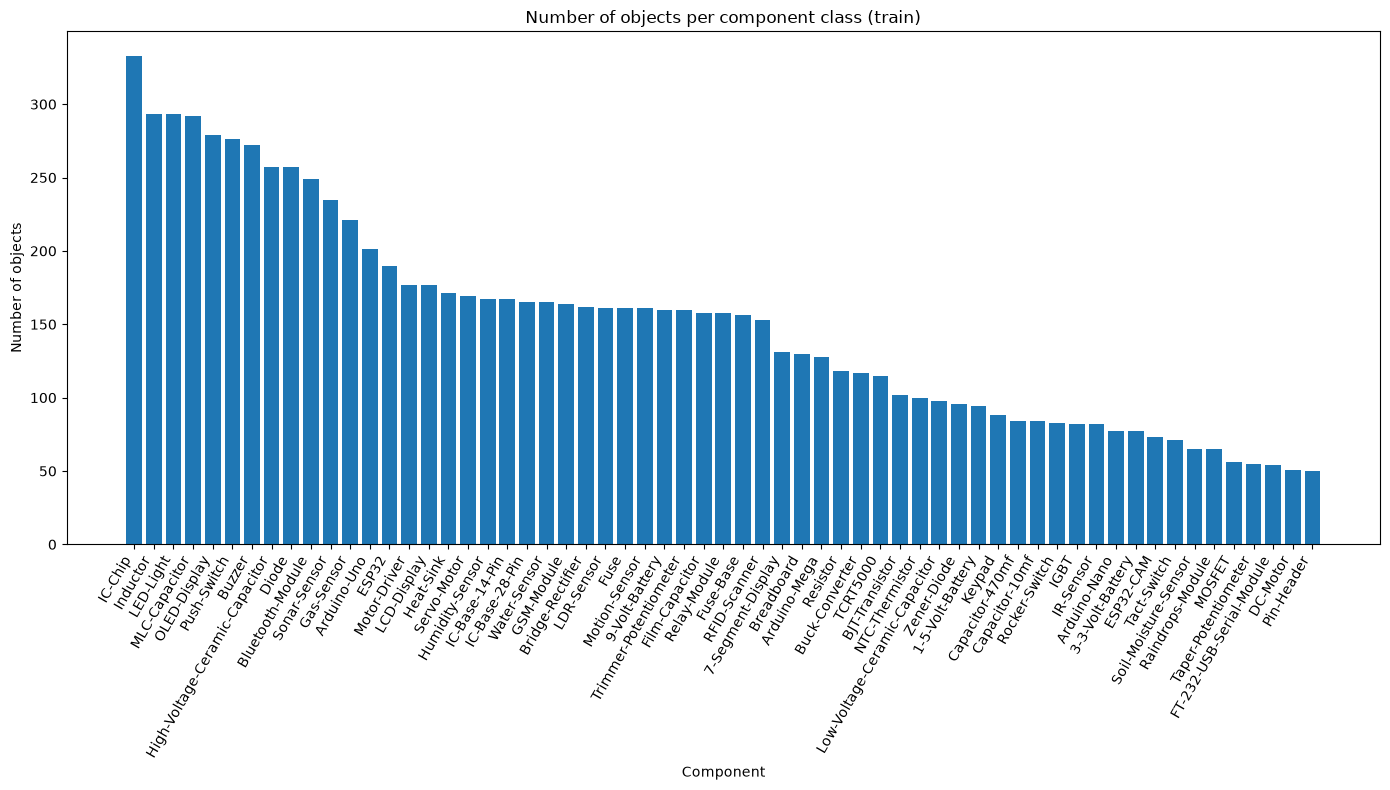

Most common: (30, 333)
Least common: (45, 50)
Imbalance ratio (max/min): 6.66


In [30]:
class_counts = Counter()

for label_file in label_dirs["train"].glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            if line.strip():
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
class_names = [names[class_id] for class_id, _ in sorted_counts]
counts = [count for _, count in sorted_counts]

plt.figure(figsize=(14, 8))
plt.bar(class_names, counts)
plt.xticks(rotation=60, ha="right")
plt.xlabel("Component")
plt.ylabel("Number of objects")
plt.title("Number of objects per component class (train)")
plt.tight_layout()
plt.show()

print("Most common:", sorted_counts[0])
print("Least common:", sorted_counts[-1])
print("Imbalance ratio (max/min):", round(sorted_counts[0][1] / sorted_counts[-1][1], 2))

## Train/valid/test representation check
Verifying if all classes exist in each split

In [31]:
def count_classes(label_dir):
    class_counts = Counter()
    for label_file in label_dir.glob("*.txt"):
        with open(label_file) as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

    return class_counts

split_counts = {split: count_classes(label_dirs[split]) for split in SPLITS}

rows = []
for class_id, name in enumerate(names):
    rows.append({
        "class": name,
        "train": split_counts["train"].get(class_id, 0),
        "valid": split_counts["valid"].get(class_id, 0),
        "test": split_counts["test"].get(class_id, 0)
    })

split_df = pd.DataFrame(rows)

missing = split_df[(split_df["valid"] == 0) | (split_df["test"] == 0)]
print(f"Classes missing in validation or test sets: {len(missing)}")
missing

Classes missing in validation or test sets: 16


,class,train,valid,test
3,9-Volt-Battery,160,0,0
8,Bluetooth-Module,249,0,0
12,Buzzer,272,0,0
17,ESP32,190,0,2
24,Gas-Sensor,221,0,0
26,High-Voltage-Ceramic-Capacitor,257,0,0
33,Inductor,293,0,0
35,LCD-Display,177,0,0
36,LDR-Sensor,161,0,0
37,LED-Light,293,0,0


16 classes out of 61 have no representation in the valid and test datasets, which means that we won't be able to properly evaluate mAP/precision/recall for these classes at all. Our choices would be to either dismiss completely these classes and accept it as a limitation of our dataset or try to move some samples with these classes to valid and test.

We are going to move 10% of the files from train to valid, and another 10% to test to compensate for the lack of representation of missing classes in valid/test splits.

In [34]:
random.seed(42)

def classes_in_label(label_path):
    with open(label_path) as f:
        return [int(line.split()[0]) for line in f if line.strip()]

def move_pair(label_file, dest_split):
    image_file = next(image_dirs["train"].glob(f"{label_file.stem}*.jpg"))
    shutil.move(str(label_file), str(label_dirs[dest_split] / label_file.name))
    shutil.move(str(image_file), str(image_dirs[dest_split] / image_file.name))

missing_class_ids = [
    class_id for class_id in range(len(names))
    if split_counts["valid"].get(class_id, 0) == 0 or split_counts["test"].get(class_id, 0) == 0
]

MOVE_FRACTION = 0.1
MIN_MOVE = 3

already_moved = set()
move_report = []

for class_id in missing_class_ids:
    class_name = names[class_id]

    candidates = []
    for label_file in label_dirs["train"].glob("*.txt"):
        if label_file.stem in already_moved:
            continue
        classes = classes_in_label(label_file)
        if class_id in classes:
            candidates.append((label_file, len(classes)))

    candidates.sort(key=lambda x: x[1])
    random.shuffle(candidates[:len(candidates) // 2])

    n_to_move = max(MIN_MOVE, int(len(candidates) * MOVE_FRACTION))

    needs_valid = split_counts["valid"].get(class_id, 0) == 0
    needs_test = split_counts["test"].get(class_id, 0) == 0

    idx = 0

    if needs_valid:
        for label_file, _ in candidates[idx:idx + n_to_move]:
            if label_file.stem in already_moved:
                continue
            move_pair(label_file, "valid")
            already_moved.add(label_file.stem)
            move_report.append({
                "class": class_name,
                "file": label_file.name,
                "dest": "valid"
            })
        idx += n_to_move

    if needs_test:
        for label_file, _ in candidates[idx:idx + n_to_move]:
            if label_file.stem in already_moved:
                continue
            move_pair(label_file, "test")
            already_moved.add(label_file.stem)
            move_report.append({
                "class": class_name,
                "file": label_file.name,
                "dest": "test"
            })

print(f"Files moved: {len(move_report)}")
pd.DataFrame(move_report)

Files moved: 403


,class,file,dest
0,9-Volt-Battery,IMG_20240220_132444_jpg.rf.23a1776c8ed64ca0265...,valid
1,9-Volt-Battery,IMG_20240220_131847_jpg.rf.57380f29a10cc21e281...,valid
2,9-Volt-Battery,IMG_20240220_135827_jpg.rf.5291b1213dba9354abd...,valid
3,9-Volt-Battery,IMG20240220135847_jpg.rf.7edf2dd3f4e612cb436dc...,valid
4,9-Volt-Battery,IMG_20240220_131851_jpg.rf.dd37f95a1759d78d923...,valid
...,...,...,...
398,Sonar-Sensor,IMG_5255_JPG.rf.6bd5e89388414c5184f7de26244f39...,test
399,Sonar-Sensor,IMG_5256_JPG.rf.d29ef020c8b083c2161d8dbabb6a6b...,test
400,Sonar-Sensor,IMG_5257_JPG.rf.0a49f85de365b4a647e78e2d7e8d62...,test
401,Sonar-Sensor,IMG_5258_JPG.rf.4312776d6bf12efb5d3f419454f132...,test


In [35]:
split_counts = {split: count_classes(label_dirs[split]) for split in SPLITS}

rows = []

for class_id, name in enumerate(names):
    rows.append({
        "class": name,
        "train": split_counts["train"].get(class_id, 0),
        "valid": split_counts["valid"].get(class_id, 0),
        "test": split_counts["test"].get(class_id, 0)
    })

split_df = pd.DataFrame(rows)

missing = split_df[(split_df["valid"] == 0) | (split_df["test"] == 0)]
print(f"Classes missing in validation or test sets after moving: {len(missing)}")
missing

Classes missing in validation or test sets after moving: 0


,class,train,valid,test


## Bounding box size distribution per class

In [37]:
box_areas = {class_id: [] for class_id in range(len(names))}

for label_file in label_dirs["train"].glob("*.txt"):
    with open(label_file) as f:
        for line in f:
            if not line.strip():
                continue
            class_id, x_center, y_center, w, h = map(float, line.split())
            box_areas[class_id].append(w * h)

area_rows = []
for class_id, areas in box_areas.items():
    if areas:
        area_rows.append({
            "class": names[class_id],
            "median_area_pct": np.median(areas) * 100,
            "mean_area_pct": np.mean(areas) * 100,
            "n": len(areas),
        })

area_df = pd.DataFrame(area_rows).sort_values("median_area_pct")
area_df.head(15)

,class,median_area_pct,mean_area_pct,n
39,MLC-Capacitor,0.279205,0.331570,224
46,Push-Switch,0.485535,0.664959,180
56,Tact-Switch,0.508423,0.760596,71
21,Fuse,0.639343,0.766107,112
12,Buzzer,0.651855,0.853238,157
58,Trimmer-Potentiometer,0.736389,1.005198,160
30,IC-Chip,0.779968,1.083877,202
33,Inductor,0.902344,1.259643,143
7,BJT-Transistor,0.912292,1.435060,102
55,TCRT5000,1.070435,1.583375,115


We might expect these classes to underperform due to their small box area.

## Cross-split duplicate images
Same image file appearing in more than one split

In [42]:
duplicate_images = {}

for split in SPLITS:
    for image_file in image_dirs[split].glob("*.jpg"):
        with open(image_file, "rb") as f:
            image_hash = hashlib.md5(f.read()).hexdigest()
            duplicate_images.setdefault(image_hash, []).append((split, image_file.name))

duplicates = {h: file for h, file in duplicate_images.items() if len(file) > 1}
cross_split_leaks = {h: file for h, file in duplicates.items() if len({s for s, _ in file}) > 1}

print(f"Total duplicate groups: {len(duplicates)}")
print(f"Cross-split leaks (duplicates in multiple splits): {len(cross_split_leaks)}")

for h, files in list(cross_split_leaks.items())[:10]:
    print(files)

Total duplicate groups: 0
Cross-split leaks (duplicates in multiple splits): 0


## Checking for false negatives in training data
Checking for unlabeled objects

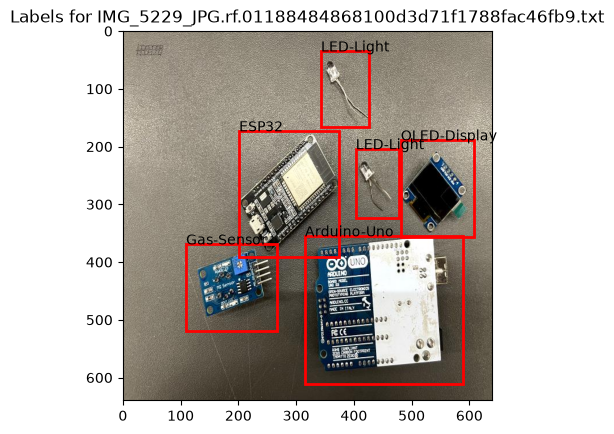

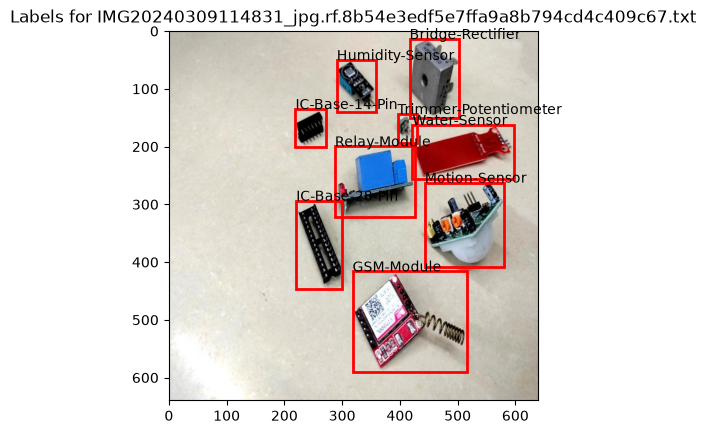

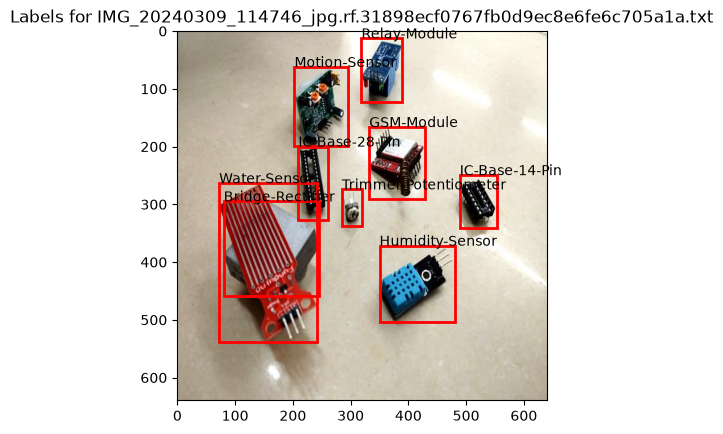

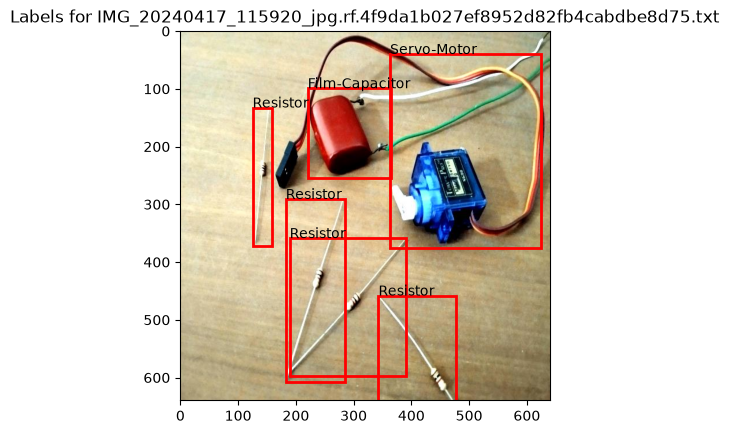

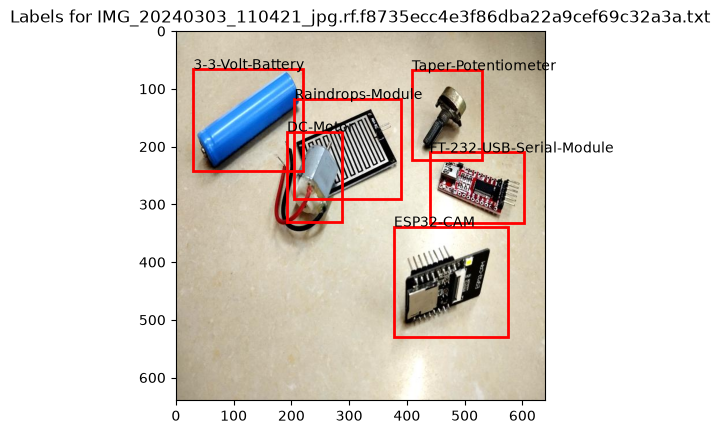

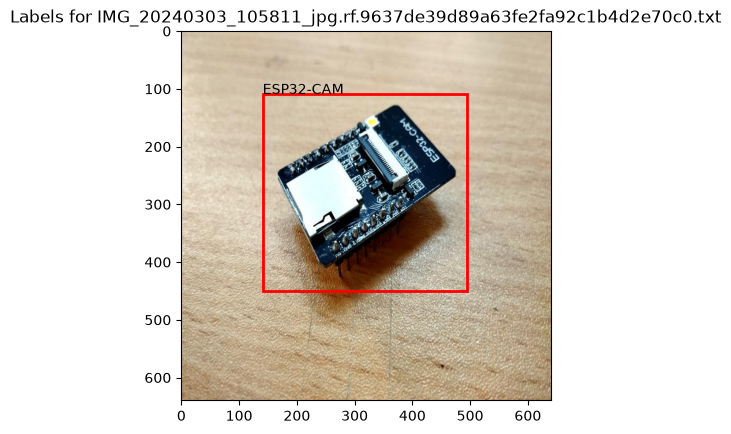

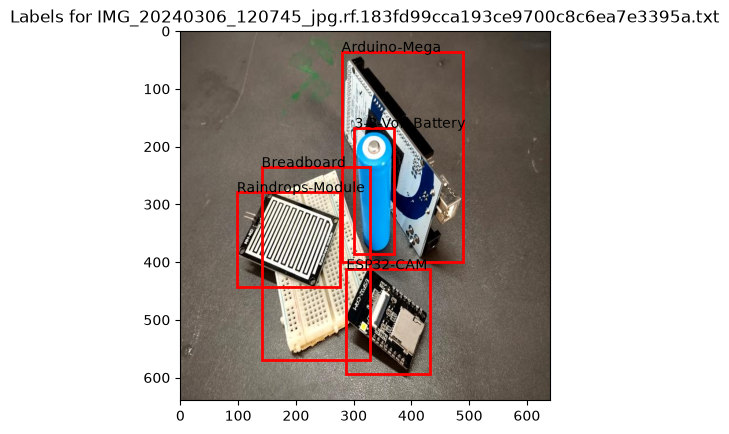

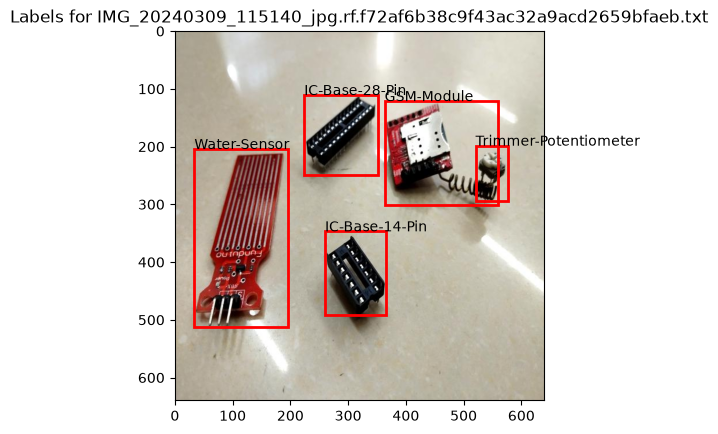

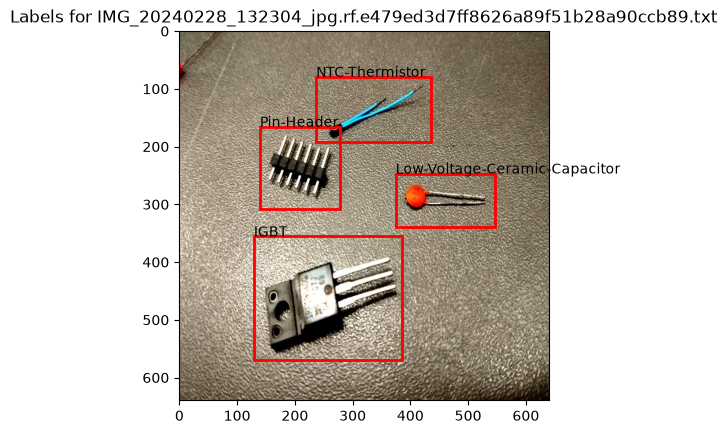

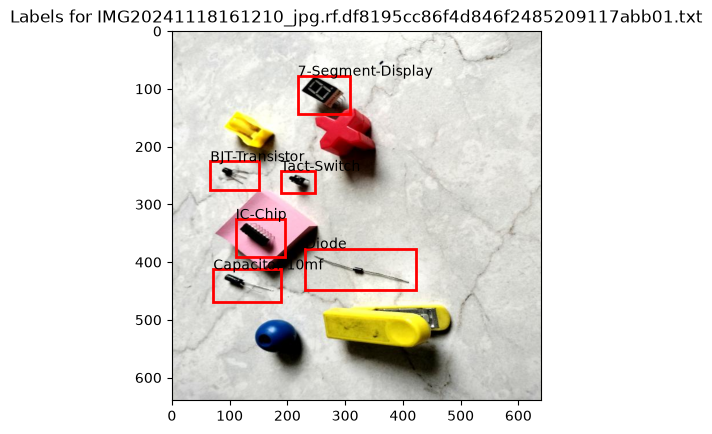

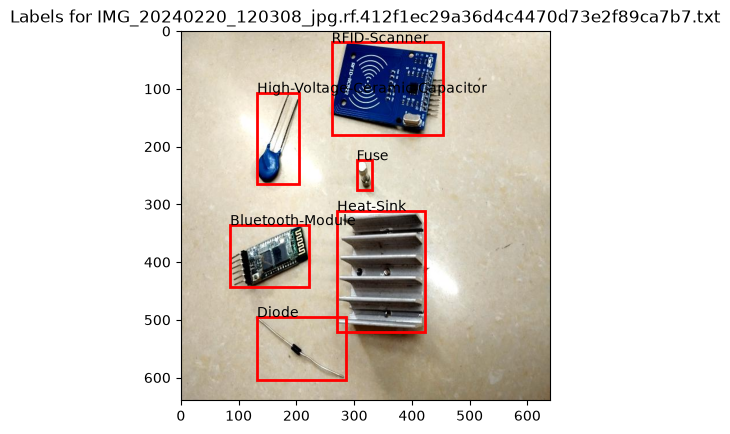

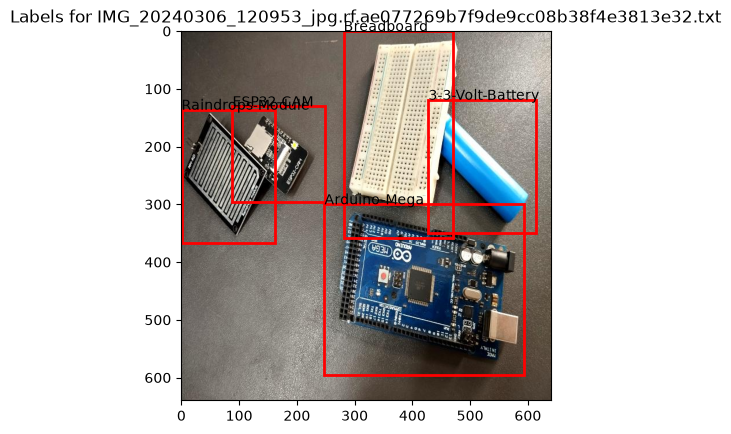

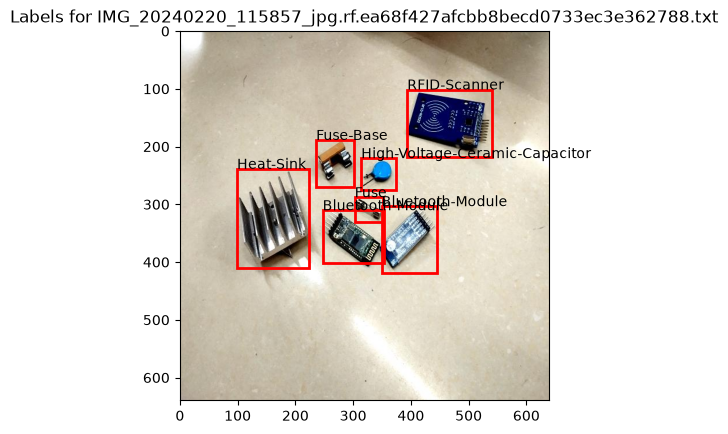

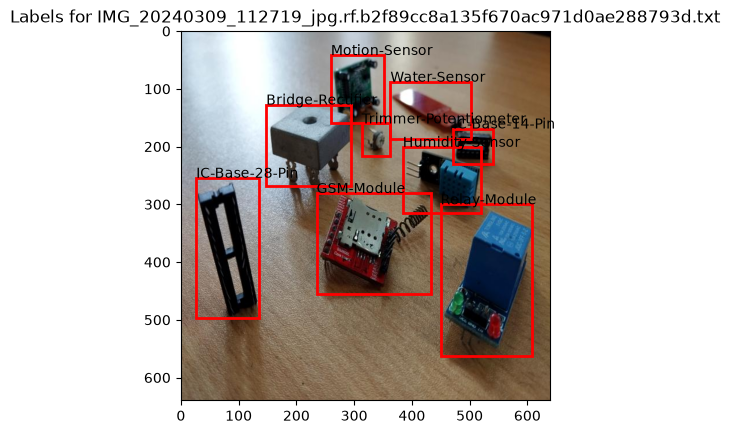

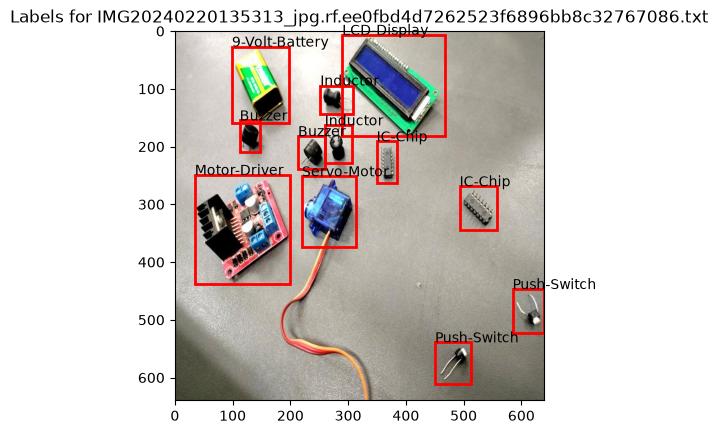

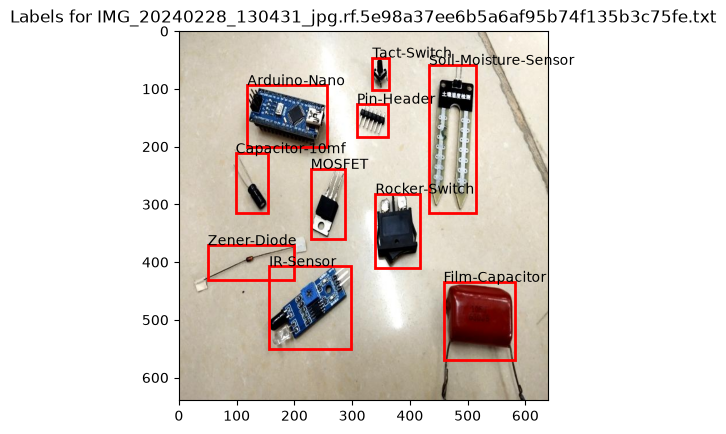

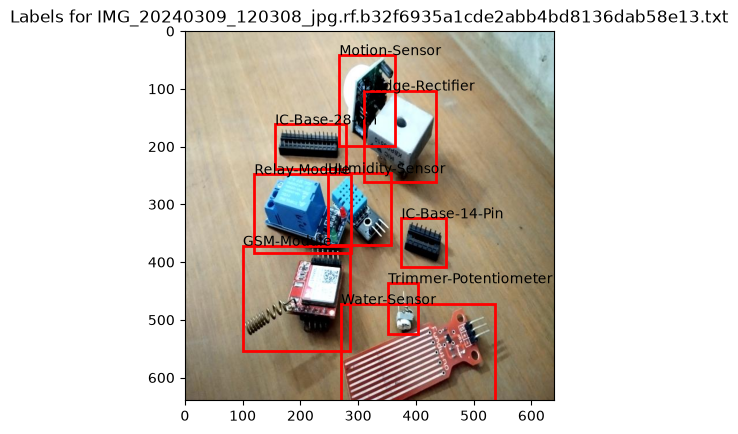

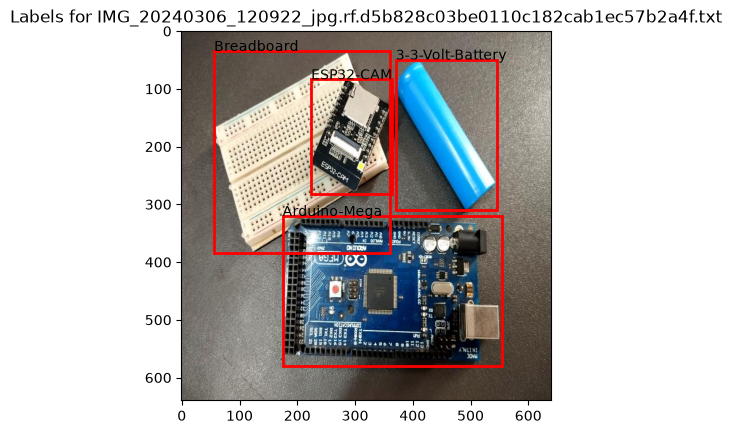

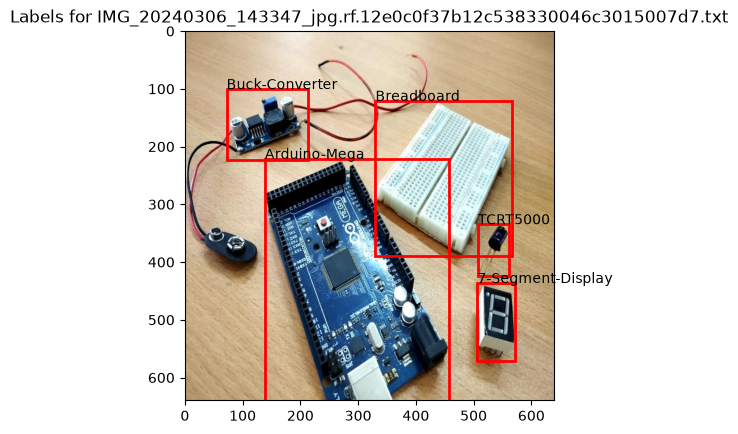

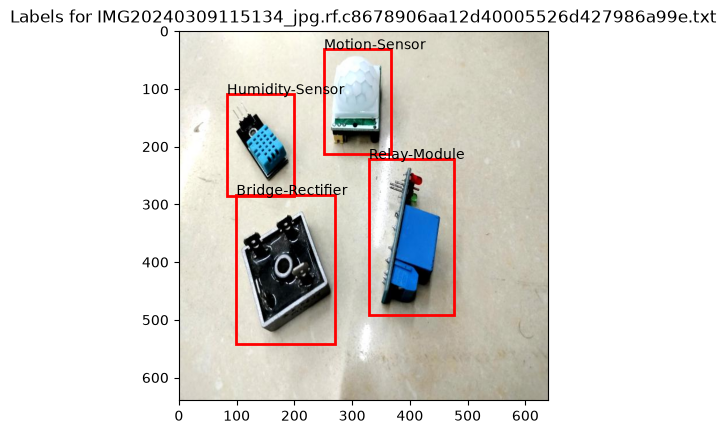

In [43]:
random_labels = random.sample(list(label_dirs["train"].glob("*.txt")), 20)

def visualize_labels(label_file):
    image_file = next(image_dirs["train"].glob(f"{label_file.stem}*.jpg"))
    image = Image.open(image_file)

    width, height = image.size
    fig, ax = plt.subplots()
    ax.imshow(image)
    ax.set_title(f"Labels for {label_file.name}")

    with open(label_file) as f:
        for line in f:
            if not line.strip():
                continue
            class_id, x_center, y_center, w, h = map(float, line.split())
            x_center *= width
            y_center *= height
            w *= width
            h *= height

            x = x_center - w / 2
            y = y_center - h / 2

            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y, names[int(class_id)])
    plt.show()

for label_file in random_labels:
    visualize_labels(label_file)

We can assume unlabeled objects are rare to very rare across this dataset and therefore won't poison our model a lot.

## Findings

**Class imbalance**: most common class has several times more instances than the rarest (view class distribution chart)

**Box-level duplicate labels**: found and fixed. Used IoU check to determine the threshold where we encounter duplicates and then removed them.

**Train/Valid/Test split problem**: in valid and test splits, 16 out of all 61 classes had zero representation, meaning they could not be evaluated. Fixed the issue by moving to each split 10% of the images belonging to those classes and prioritizing the images with lower number of objects per image to minimize side effects on other classes.

**Small object risk**: computed bounding box size per class. Smallest classes by median box area: MLC-Capacitor, Push-Switch,
Tact-Switch, Fuse, Buzzer, Trimmer-Potentiometer, IC-Chip, Inductor, BJT-Transistor, TCRT5000, Low-Voltage-Ceramic-Capacitor, LDR-Sensor, NTC-Thermistor, Pin-Header, IC-Base-14-Pin.  Classes with the smallest bounding box are assume to underperform in later evaluation regardless of instance count, because small boxes are more prone to being overshadowed by larger co-occuring components.

**Cross-split image leakage**: check and found none. Performed MD5 hash comparison across all three split and founds 0 duplicate images spanning more than one split, therefore being safe to trust validation/test metrics.

**Missing-label rate**: manual audit of 20 random train images and found 0 with unlabeled objects. Discovered one anecdotal case outside of this sample, however we can assume cases of unlabeled objects are very rare and therefore won't address given the low rate.